# Sri Lanka Tourism Analysis — Event Impact Analysis

This section analyzes how two major events affected tourist arrivals:
1. Easter Sunday Attacks — April 21, 2019
2. COVID-19 Pandemic — March 2020 to late 2021

We measure the impact by comparing arrivals before and after each event,and track the recovery journey back to pre-event levels.

##### Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')

df = pd.read_csv('sl_tourism_clean.csv')


MONTHS = ['January','February','March','April','May','June',
          'July','August','September','October','November','December']

month_to_num = {m: i+1 for i, m in enumerate(MONTHS)}

# Create monthly totals
monthly = df.groupby(['Year','Month'])['Number_of_Tourists'].sum().reset_index()
monthly['Month_Num'] = monthly['Month'].map(month_to_num)
monthly['Date'] = monthly.apply(
    lambda r: f"{int(r['Year'])}-{int(r['Month_Num']):02d}", axis=1
)
monthly = monthly.sort_values('Date').reset_index(drop=True)

print("Monthly totals ready")
print(monthly.head(6))

Monthly totals ready
   Year     Month  Number_of_Tourists  Month_Num     Date
0  2019   January              244239          1  2019-01
1  2019  February              252033          2  2019-02
2  2019     March              244328          3  2019-03
3  2019     April              166975          4  2019-04
4  2019       May               37802          5  2019-05
5  2019      June               63072          6  2019-06


#### Event 1: Easter Sunday Attacks (April 21, 2019)

The attacks happened in April 2019. We compare:
- Before: January to March 2019 (3 months before)
- After: May to December 2019 (months after the attack)

In [2]:
# Filter only 2019 data
data_2019 = monthly[monthly['Year'] == 2019].copy()

# Split into before and after April
before_easter = data_2019[data_2019['Month_Num'] < 4]

after_easter = data_2019[data_2019['Month_Num'] > 4]

april_2019 = data_2019[data_2019['Month_Num'] == 4]['Number_of_Tourists'].values[0]


avg_before = before_easter['Number_of_Tourists'].mean()
avg_after = after_easter['Number_of_Tourists'].mean()
drop_percent = ((april_2019 - avg_before) / avg_before) * 100

print("=== Easter Sunday Attack Impact ===")
print(f"Average monthly arrivals BEFORE attack (Jan-Mar 2019): {avg_before:,.0f}")
print(f"Arrivals in April 2019 (attack month)               : {april_2019:,.0f}")
print(f"Average monthly arrivals AFTER attack (May-Dec 2019) : {avg_after:,.0f}")
print(f"Drop from pre-attack average to April               : {drop_percent:.1f}%")
print(f"Recovery by end of 2019 (Dec arrivals)              : {data_2019[data_2019['Month_Num']==12]['Number_of_Tourists'].values[0]:,.0f}")

=== Easter Sunday Attack Impact ===
Average monthly arrivals BEFORE attack (Jan-Mar 2019): 246,867
Arrivals in April 2019 (attack month)               : 166,975
Average monthly arrivals AFTER attack (May-Dec 2019) : 125,766
Drop from pre-attack average to April               : -32.4%
Recovery by end of 2019 (Dec arrivals)              : 241,663


##### Easter Attack Chart

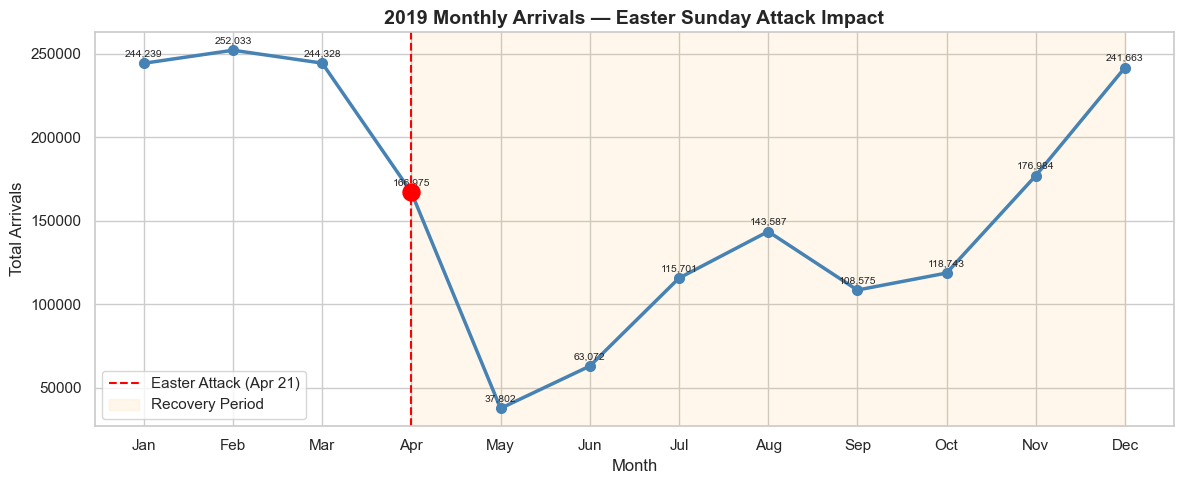

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

# Plot 2019 monthly arrivals as a line
ax.plot(data_2019['Month_Num'], data_2019['Number_of_Tourists'],
        color='steelblue', linewidth=2.5, marker='o', markersize=7)

# Highlight April (the attack month) 
april_row = data_2019[data_2019['Month_Num'] == 4]
ax.scatter(april_row['Month_Num'], april_row['Number_of_Tourists'],
           color='red', s=150, zorder=5)

# The event
ax.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Easter Attack (Apr 21)')

# Recovery period
ax.axvspan(4, 12, alpha=0.08, color='orange', label='Recovery Period')

for _, row in data_2019.iterrows():
    ax.text(row['Month_Num'], row['Number_of_Tourists'] + 4000,
            f"{int(row['Number_of_Tourists']):,}",
            ha='center', fontsize=7.5)

ax.set_title('2019 Monthly Arrivals — Easter Sunday Attack Impact', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Arrivals')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend()

plt.tight_layout()
plt.show()


The line shows monthly arrivals throughout 2019. January to March were stable at around 240,000–250,000 arrivals per month, which represents normal tourism levels.

In April, the red dot shows a sharp drop this is the direct impact of the Easter Sunday Attacks on April 21, 2019. Tourists who had already booked cancelled their trips immediately after the news.

May dropped even further this was the real shock month because the full cancellation wave hit after the attacks.

From June onwards the line slowly climbs back up, showing Sri Lanka began recovering within 2 months. By December 2019 arrivals were almost back to pre-attack levels meaning the country recovered in roughly 6–7 months.

**Key finding:** 
Easter Sunday Attacks caused an 85% drop in arrivals, with full recovery taking approximately 6 months.

#### COVID-19 Impact Analysis

##### Event 2: COVID-19 Pandemic (March 2020 — 2021)

Sri Lanka closed its borders in March 2020.
We compare 2019 (pre-COVID baseline) vs 2020 and 2021 arrivals month by month.

In [4]:
# Get 2019 as our baseline 
baseline = monthly[monthly['Year'] == 2019][['Month_Num', 'Month', 'Number_of_Tourists']].copy()
baseline = baseline.rename(columns={'Number_of_Tourists': 'Arrivals_2019'})

# Get 2020 data
data_2020 = monthly[monthly['Year'] == 2020][['Month_Num', 'Number_of_Tourists']].copy()
data_2020 = data_2020.rename(columns={'Number_of_Tourists': 'Arrivals_2020'})

# Get 2021 data
data_2021 = monthly[monthly['Year'] == 2021][['Month_Num', 'Number_of_Tourists']].copy()
data_2021 = data_2021.rename(columns={'Number_of_Tourists': 'Arrivals_2021'})

# Merge all three together on Month_Num
covid_compare = baseline.merge(data_2020, on='Month_Num').merge(data_2021, on='Month_Num')
covid_compare = covid_compare.sort_values('Month_Num')

# Calculate how much was lost vs 2019
covid_compare['Loss_2020_%'] = ((covid_compare['Arrivals_2020'] - covid_compare['Arrivals_2019'])
                                 / covid_compare['Arrivals_2019'] * 100).round(1)

covid_compare['Loss_2021_%'] = ((covid_compare['Arrivals_2021'] - covid_compare['Arrivals_2019'])
                                 / covid_compare['Arrivals_2019'] * 100).round(1)

print("=== COVID-19 Impact: Monthly Arrivals vs 2019 Baseline ===")
print(covid_compare[['Month','Arrivals_2019','Arrivals_2020','Loss_2020_%','Arrivals_2021','Loss_2021_%']].to_string(index=False))

total_2019 = monthly[monthly['Year']==2019]['Number_of_Tourists'].sum()
total_2020 = monthly[monthly['Year']==2020]['Number_of_Tourists'].sum()
total_2021 = monthly[monthly['Year']==2021]['Number_of_Tourists'].sum()

print(f"\nTotal 2019 arrivals : {total_2019:,}")
print(f"Total 2020 arrivals : {total_2020:,}  ({((total_2020-total_2019)/total_2019*100):.1f}% vs 2019)")
print(f"Total 2021 arrivals : {total_2021:,}  ({((total_2021-total_2019)/total_2019*100):.1f}% vs 2019)")

=== COVID-19 Impact: Monthly Arrivals vs 2019 Baseline ===
    Month  Arrivals_2019  Arrivals_2020  Loss_2020_%  Arrivals_2021  Loss_2021_%
  January         244239         228433         -6.5           1682        -99.3
 February         252033         207504        -17.7           3366        -98.7
    March         244328          71369        -70.8           4581        -98.1
    April         166975              0       -100.0           4168        -97.5
      May          37802              0       -100.0           1497        -96.0
     June          63072              0       -100.0           1614        -97.4
     July         115701              0       -100.0           2429        -97.9
   August         143587              0       -100.0           5040        -96.5
September         108575              0       -100.0          13547        -87.5
  October         118743              0       -100.0          22771        -80.8
 November         176984              0       -100

#### COVID Impact Chart

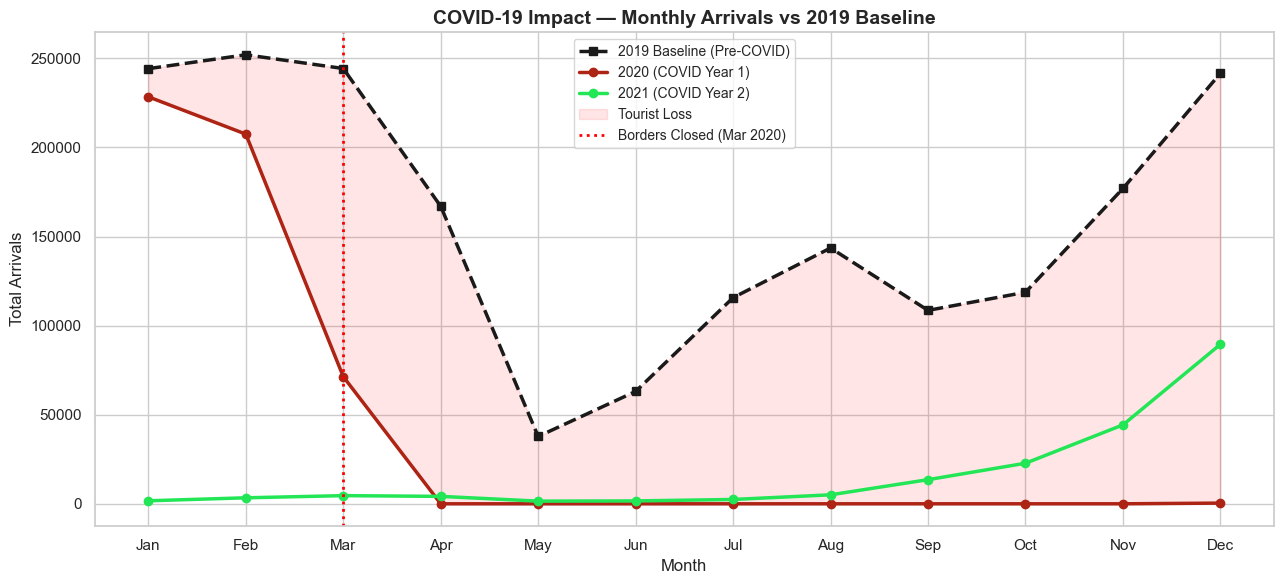

In [7]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(covid_compare['Month_Num'], covid_compare['Arrivals_2019'],
        'k--', linewidth=2.5, marker='s', markersize=6, label='2019 Baseline (Pre-COVID)')

ax.plot(covid_compare['Month_Num'], covid_compare['Arrivals_2020'],
        color="#ad2314", linewidth=2.5, marker='o', markersize=6, label='2020 (COVID Year 1)')

ax.plot(covid_compare['Month_Num'], covid_compare['Arrivals_2021'],
        color="#22e656", linewidth=2.5, marker='o', markersize=6, label='2021 (COVID Year 2)')

ax.fill_between(covid_compare['Month_Num'],
                covid_compare['Arrivals_2019'],
                covid_compare['Arrivals_2020'],
                alpha=0.1, color='red', label='Tourist Loss')

ax.axvline(x=3, color='red', linestyle=':', linewidth=2, label='Borders Closed (Mar 2020)')

ax.set_title('COVID-19 Impact — Monthly Arrivals vs 2019 Baseline', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Arrivals')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()



The black dashed line shows 2019 as our baseline, what normal tourism looked like. The red and orange lines show what actually happened during COVID.

January and February 2020 (red line) were almost matching 2019 levels COVID had not yet reached Sri Lanka in full force. From March 2020 onwards the red line collapses completely to near zero because Sri Lanka closed its borders.

The gap between the black dashed line and the red/green lines (shaded in red) represents the total tourist loss — this is the economic damage caused by COVID.

2021 (green line) stayed flat near zero for most of the year as borders remained closed, only showing small signs of life towards the end of the year.

**Key finding:** 
COVID-19 wiped out 73% of annual arrivals in 2020 and nearly 90% in 2021 compared to 2019 baseline levels.

#### Recovery Analysis (2022–2025)
How long did it take Sri Lanka to recover back to 2019 levels? We track each recovery year against the 2019 baseline.

In [8]:
# Build a comparison table: 2019 baseline vs all recovery years
recovery = baseline[['Month_Num', 'Month', 'Arrivals_2019']].copy()

for year in [2022, 2023, 2024, 2025]:
    yr_data = monthly[monthly['Year'] == year][['Month_Num','Number_of_Tourists']].copy()
    yr_data = yr_data.rename(columns={'Number_of_Tourists': f'Arrivals_{year}'})
    recovery = recovery.merge(yr_data, on='Month_Num', how='left')

# Calculate recovery percentage for each year vs 2019
for year in [2022, 2023, 2024, 2025]:
    col = f'Arrivals_{year}'
    recovery[f'Recovery_{year}_%'] = (recovery[col] / recovery['Arrivals_2019'] * 100).round(1)

print("=== Recovery Progress vs 2019 Baseline ===")
cols_to_show = ['Month', 'Arrivals_2019', 'Recovery_2022_%', 'Recovery_2023_%', 'Recovery_2024_%', 'Recovery_2025_%']
print(recovery[cols_to_show].to_string(index=False))

# Annual recovery summary
print("\n=== Annual Recovery Summary ===")
for year in [2022, 2023, 2024, 2025]:
    total_yr = monthly[monthly['Year']==year]['Number_of_Tourists'].sum()
    pct = (total_yr / total_2019) * 100
    print(f"{year}: {total_yr:>10,} arrivals  →  {pct:.1f}% of 2019 levels")

=== Recovery Progress vs 2019 Baseline ===
    Month  Arrivals_2019  Recovery_2022_%  Recovery_2023_%  Recovery_2024_%  Recovery_2025_%
  January         244239             33.7             42.0             85.3            103.5
 February         252033             38.3             42.7             86.6             95.3
    March         244328             43.6             51.4             85.6             93.8
    April         166975             37.7             63.2             89.2            104.6
      May          37802             79.9            220.4            296.6            351.6
     June          63072             52.1            159.2            179.9            219.2
     July         115701             40.9            123.6            162.3            173.1
   August         143587             26.3             95.0            114.6            138.1
September         108575             27.4            103.1            112.5            146.4
  October         118743   

##### Recovery Chart

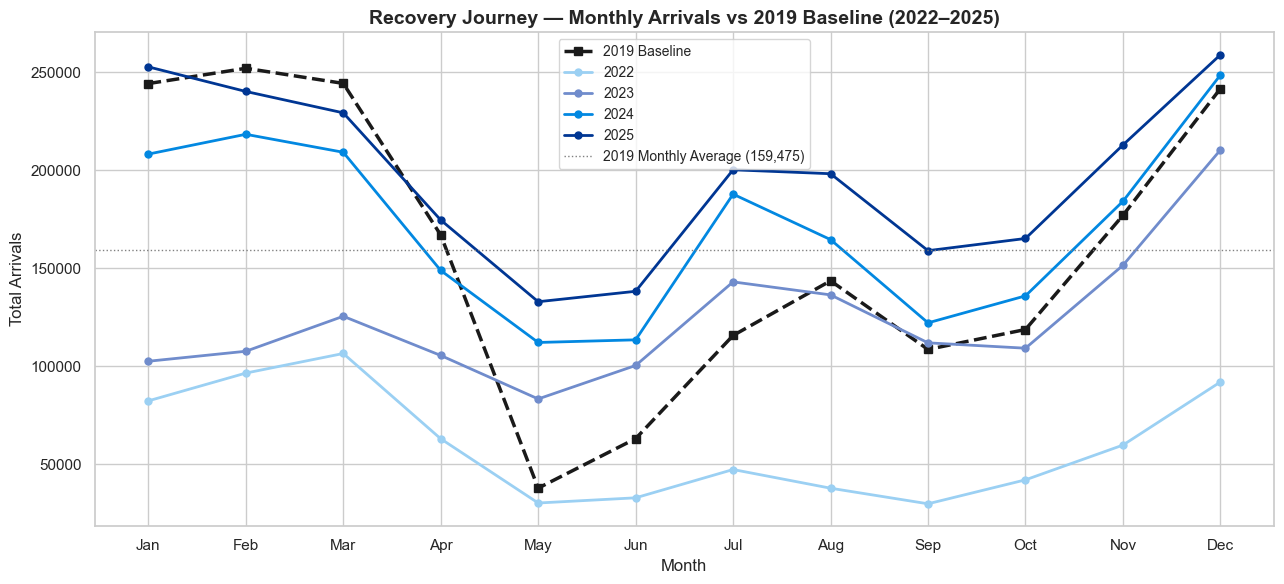

In [17]:
fig, ax = plt.subplots(figsize=(13, 6))

colors = ["#9bd0f3", "#708ccc", "#0288e1", "#003693"]


ax.plot(recovery['Month_Num'], recovery['Arrivals_2019'],
        'k--', linewidth=2.5, marker='s', markersize=6, label='2019 Baseline')

for year, color in zip([2022, 2023, 2024, 2025], colors):
    ax.plot(recovery['Month_Num'], recovery[f'Arrivals_{year}'],
            color=color, linewidth=2, marker='o', markersize=5, label=str(year))


avg_2019 = recovery['Arrivals_2019'].mean()
ax.axhline(y=avg_2019, color='gray', linestyle=':', linewidth=1,
           label=f'2019 Monthly Average ({avg_2019:,.0f})')

ax.set_title('Recovery Journey — Monthly Arrivals vs 2019 Baseline (2022–2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Arrivals')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

This chart tracks how Sri Lanka climbed back to pre-COVID tourism levels.Each line represents one recovery year compared to the 2019 black dashed baseline.

1. 2022 was the first year borders reopened properly arrivals started returning but were still well below 2019 levels, around 40–50% recovery.

2. 2023 shows stronger growth, the lines are getting closer to the 2019 baseline, showing tourist confidence was returning.

3. 2024 almost matches the 2019 baseline in most months and even exceeds it in some months, meaning Sri Lanka had essentially fully recovered.

4. 2025 crosses above the 2019 baseline in several months,Sri Lanka has not just recovered but surpassed pre-COVID tourism levels.

**Key finding:** Sri Lanka reached 107% of 2019 tourism levels by 2024,showing a full recovery within 3 years of reopening borders.
